# ML Drought Forecasting

I am going to be predicting spi3 and spi6 three months ahead using 12 months of historical climate conditions. While doing this, I am comparing 3 different ML models against a climatological and persistence baseline in order to see which is most effective (and also therefore highlighting what type of relationship drought has with the variables) and which is less so. The models being created are as follows:

- Ridge Regression  
- Random Forest 
- Gradient Boosting

No deep learning models have been selected, as there is really not any practical point with a dataset size so small. The reasons for the selected model are below:

**Ridge Regression**    
- Baseline linear model, if it works the variable relationship to drought is simple and linear. 
- Will immediately make it clear if random forest/gradient boosting are going to be better models.  

**Random Forest**   
- Robust and works well with small datasets.    
- Shows non linear relationships between the variables and drought, showing if variables are working together for prediction.   
- Shows feature importance, will highlight which variables and data points are most important in prediction.    

**Gradient Boosting**   
- Will notice more subtle patterns for non linear relationships that random forest cannot see.  
- Learning rate is an easy tool I can tweak to control complexity of prediction.    

There are going to be two baselines for the model to have to beat. The two baselines are climatological and also persistence, if it can beat both it concretely shows that the model is good enough to predict future drought conditions. These baselines are:

**Climatological Baseline**
- Question: "I am predicting the historical average every time".    
- Test: Can the model beat this prediction knowing nothing about the conditions during the prediction date. 

**Persistence Baseline**
- Question: "I am predicting that SPI6 in 3 months will be identical to what it is today".     
- Test: Can the model beat the assumption that absolutely nothing is going to change.   

The final part of the model creation and forecasting is temporal split. In order to avoid the model ever seeing the data it is being tested on during training, I am going to split it in two. To maximise the amount of training data available to the model, **1980-2019** will all be training data, and then 2020-2024 will be used to test the model and to run predictions upon.

**Note**    
While it will be explained in greater detail in the summary section at the end of this notebook, I attempted to introduce El Niño Southern Oscillation to this project as persistence is a difficult baseline to beat with spi6 especially, due to it semi involving existing data and as such Xt = Xt+1 will predict fairly accurately​. Despite this however, it makes it worse due to just making too much noise, and so was removed.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import urllib.request

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
bcolor="darkslategrey"

df = pd.read_csv("../data/processed/mendoza_basin_with_indices.csv", parse_dates=["time"], index_col="time")

print(f"Loaded {len(df)} months")
print(f"NaN counts:\n{df.isnull().sum()}")

# Feature Config
target_3 = "spi3"
target_6 = "spi6"
horizon = 3
lookback = 12
test_years = 5

Loaded 540 months
NaN counts:
precip_mm               0
temp_c                  0
pev_mm                  0
runoff_mm               0
soil_moisture_0_7cm     0
spi3                    2
spi6                    5
spi12                  11
spei3                   2
spei6                   5
dtype: int64


## Feature Engineering

I transform the dataset into a supervised learning problem. For every prediction, I use 12 months of lookback across 6 variables as features, and also cyclical month encoding to capture seasonality.

In [6]:
df_clean = df.dropna()
print(f"Months available: {len(df_clean)}")

def create_supervised_dataset(data, target_col, features_cols, horizon, lookback):
    x_rows = []
    y_rows = []
    dates = []
    col_names = []

    for i in range(lookback, len(data) - horizon):
        window = data.iloc[i - lookback:i][features_cols].values
        features = window.flatten()
        current_month = data.index[i].month
        month_sin = np.sin(2 * np.pi * current_month / 12)
        month_cos = np.cos(2 * np.pi * current_month / 12)
        features = np.append(features, [month_sin, month_cos])
        target = data.iloc[i + horizon][target_col]

        x_rows.append(features)
        y_rows.append(target)
        dates.append(data.index[i + horizon])
    
    for lag in range(lookback, 0, -1):
        for ftre in features_cols:
            col_names.append(f"{ftre}_lag{lag}")
    col_names.extend(["month_sin", "month_cos"])
    
    x = pd.DataFrame(x_rows, columns=col_names, index=dates)
    y = pd.Series(y_rows, index=dates, name=target_col)

    return x, y

Months available: 529


## Feature Engineering Improvements

Testing whether selective lag features and rate of change variables improve forecast skill beyond the base feature set. While the current results of the regression models is acceptable, I am hoping that I can improve them in persistence a couple percent, and maybe get to at least a neutral R².

In [12]:
df_clean["spi6_change_1m"] = df_clean["spi6"].diff(1)
df_clean["spi6_change_3m"] = df_clean["spi6"].diff(3)
df_clean["precip_change_3m"] = df_clean["precip_mm"].diff(3)
df_clean["soil_change_3m"] = df_clean["soil_moisture_0_7cm"].diff(3)
df_clean = df_clean.dropna()

print(f"Months available: {len(df_clean)}")

features_base = [
    "precip_mm",
    "temp_c",
    "pev_mm",
    "runoff_mm",
    "soil_moisture_0_7cm",
    "spi3",
    "spi6",
]
features_enhanced = [
    "precip_mm",
    "temp_c",
    "pev_mm",
    "runoff_mm",
    "soil_moisture_0_7cm",
    "spi3",
    "spi6",
    "spi6_change_1m",
    "spi6_change_3m",
    "precip_change_3m",
    "soil_change_3m",
]
features_spi3 = [
    "precip_mm",
    "temp_c",
    "pev_mm",
    "runoff_mm",
    "soil_moisture_0_7cm",
    "spi6",
]

x_base, y_base = create_supervised_dataset(df_clean, "spi6", features_base, horizon, lookback)
x_enhance, y_enhance = create_supervised_dataset(df_clean, "spi6", features_enhanced, horizon, lookback)
x_spi3, y_spi3 = create_supervised_dataset(df_clean, "spi3", features_spi3, horizon, lookback)

drop_col = [col for col in x_enhance.columns
            if "spi6_lag" in col
            and int(col.split("lag")[1]) > 4]
x_enhance = x_enhance.drop(columns=drop_col)

print(f"\nBase SPI6 Features:     {x_base.shape[1]}")
print(f"\nEnhanced SPI6 Features: {x_enhance.shape[1]}")
print(f"\nSPI3 Features:          {x_spi3.shape[1]}")

def quick_test(x, y, label):
    cutoff = x.index.max() - pd.DateOffset(years=test_years)
    x_tr, x_te = x[x.index <= cutoff], x[x.index > cutoff]
    y_tr, y_te = y[y.index <= cutoff], y[y.index > cutoff]

    rf = RandomForestRegressor(
        n_estimators=200, 
        max_depth=10, 
        min_samples_leaf=5, 
        random_state=42,
        )
    rf.fit(x_tr, y_tr)
    y_pred = rf.predict(x_te)

    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2 = r2_score(y_te, y_pred)

    persist = []
    for target_date in y_te.index:
        fd = target_date - pd.DateOffset(months=horizon)
        if fd in df_clean.index:
            persist.append(df_clean.loc[fd, "spi6"])
        else:
            closest = df_clean.index.get_indexer([fd], method="nearest")[0]
            persist.append(df_clean.iloc[closest]["spi6"])
    persist_rmse = np.sqrt(mean_squared_error(y_te, np.array(persist)))
    skill = 1 - (rmse / persist_rmse)

    print(f"  {label:25s} RMSE: {rmse:.3f}  R²: {r2:.3f}  Skill vs Persist: {skill:+.3f}")
    return skill

print("\nSPI6 feature comparison (Random Forest):")
skill_base = quick_test(x_base, y_base, "Base")
skill_enhanced = quick_test(x_enhance, y_enhance, "Enhanced")

if skill_enhanced > skill_base:
    x_6, y_6 = x_enhance, y_enhance
    print(f"\nUsing enhanced features (better by {skill_enhanced - skill_base:.3f})")
else:
    x_6, y_6 = x_base, y_base
    print(f"\nUsing base features (enhanced didn't help)")

Months available: 517

Base SPI6 Features:     86

Enhanced SPI6 Features: 126

SPI3 Features:          74

SPI6 feature comparison (Random Forest):
  Base                      RMSE: 0.822  R²: -0.188  Skill vs Persist: +0.043
  Enhanced                  RMSE: 0.847  R²: -0.260  Skill vs Persist: +0.015

Using base features (enhanced didn't help)


## Training and Testing Split

In order to keep good temporal space, the training and testing data are complete separate so that the model never sees the future data. The training data is going to be **1980-2019**, and the testing data is going to be **2020-2024**.

In [13]:
def temporal_split(x, y, test_years):
    cutoff = x.index.max() - pd.DateOffset(years=test_years)

    x_train = x[x.index <= cutoff]
    y_train = y[y.index <= cutoff]
    x_test = x[x.index > cutoff]
    y_test = y[y.index > cutoff]
    return x_train, y_train, x_test, y_test

x_train3, y_train3, x_test3, y_test3 = temporal_split(x_3, y_3, test_years)
x_train6, y_train6, x_test6, y_test6 = temporal_split(x_6, y_6, test_years)

scaler_3 = StandardScaler()
x_train3_scaled = scaler_3.fit_transform(x_train3)
x_test3_scaled = scaler_3.fit_transform(x_test3)

scaler_6 = StandardScaler()
x_train6_scaled = scaler_6.fit_transform(x_train6)
x_test6_scaled = scaler_6.fit_transform(x_test6)

## Model Training and Evaluation

Comparing three models against a climatological baseline and a persistence baseline. The skill score measures improvement over this baseline, a positive value means the model adds value beyond simple historical averages.

In [14]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": round(mae, 3),
        "RMSE": round(rmse, 3),
        "R²": round(r2, 3),
    }

def run_model(x_train, x_test, x_train_scaled, x_test_scaled, y_train, y_test, df_clean, target_col, label):
    # Climatological Baseline
    clim_pred = np.full(len(y_test), y_train.mean())
    clim_metrics = evaluate_model(y_test, clim_pred, "Climatology Baseline")
    clim_rmse = clim_metrics["RMSE"]

    # Persistence Baseline
    persistence_pred = []
    for target_date in y_test.index:
        forecast_date = target_date - pd.DateOffset(months=horizon)

        if forecast_date in df_clean.index:
            persistence_pred.append(df_clean.loc[forecast_date, target_col])
        else:
            closest_idx = df_clean.index.get_indexer([forecast_date], method="nearest")[0]
            persistence_pred.append(df_clean.iloc[closest_idx][target_col])

    persistence_pred = np.array(persistence_pred)
    persist_metrics = evaluate_model(y_test, persistence_pred, "Persistence Baseline")
    persist_rmse = persist_metrics["RMSE"]

    models = {
        "Ridge Regression": Ridge(alpha=1.0),
        "Random Forest": RandomForestRegressor(
            n_estimators=200,
            max_depth=4,
            min_samples_leaf=5,
            random_state=40,
        ),
        "Gradient Boosting": GradientBoostingRegressor(
            n_estimators=200,
            max_depth=10,
            learning_rate=0.05,
            min_samples_leaf=5,
            random_state=40,
        ),
    }

    all_metrics = []
    predictions = {}

    for name, pred, metrics in [("Climatology Baseline", clim_pred, clim_metrics), ("Persistence Baseline", persistence_pred, persist_metrics)]:
        metrics["Skill vs Clim"] = round(1 - (metrics["RMSE"] / clim_rmse), 3)
        metrics["Skill vs Persist"] = round(1 - (metrics["RMSE"] / persist_rmse), 3)
        all_metrics.append(metrics)
        predictions[name] = pred

    for name, model in models.items():
        if "Ridge" in name:
            model.fit(x_train_scaled, y_train)
            y_pred = model.predict(x_test_scaled)
        else:
            model.fit(x_train, y_train)
            y_pred = model.predict(x_test)
    
        metrics = evaluate_model(y_test, y_pred, name)
        metrics["Skill vs Clim"] = round(1 - (metrics["RMSE"] / clim_rmse), 3)
        metrics["Skill vs Persist"] = round(1 - (metrics["RMSE"] / persist_rmse), 3)
        all_metrics.append(metrics)
        predictions[name] = y_pred

    results_df = pd.DataFrame(all_metrics)
    print(f"\nTarget: {label}")
    print(results_df.to_string(index=False))
    return results_df, predictions, models

results_df3, predictions_3, models_3 = run_model(x_train3, x_test3, x_train3_scaled, x_test3_scaled, y_train3, y_test3, df_clean, "spi3", "SPI3")
results_df6, predictions_6, models_6 = run_model(x_train6, x_test6, x_train6_scaled, x_test6_scaled, y_train6, y_test6, df_clean, "spi6", "SPI6")


Target: SPI3
               Model   MAE  RMSE     R²  Skill vs Clim  Skill vs Persist
Climatology Baseline 1.075 1.247 -0.887          0.000             0.094
Persistence Baseline 1.088 1.377 -1.299         -0.104             0.000
    Ridge Regression 1.141 1.339 -1.175         -0.074             0.028
       Random Forest 0.892 1.053 -0.344          0.156             0.235
   Gradient Boosting 0.938 1.139 -0.575          0.087             0.173

Target: SPI6
               Model   MAE  RMSE     R²  Skill vs Clim  Skill vs Persist
Climatology Baseline 1.095 1.235 -1.681          0.000            -0.438
Persistence Baseline 0.681 0.859 -0.298          0.304             0.000
    Ridge Regression 1.080 1.219 -1.613          0.013            -0.419
       Random Forest 0.706 0.831 -0.214          0.327             0.033
   Gradient Boosting 0.717 0.842 -0.245          0.318             0.020


## Model Visualisation

Comparing model predictions against actual SPI6 values over the test period (2020–2024). The shaded red zone indicates drought conditions (SPI-6 < −1.0).

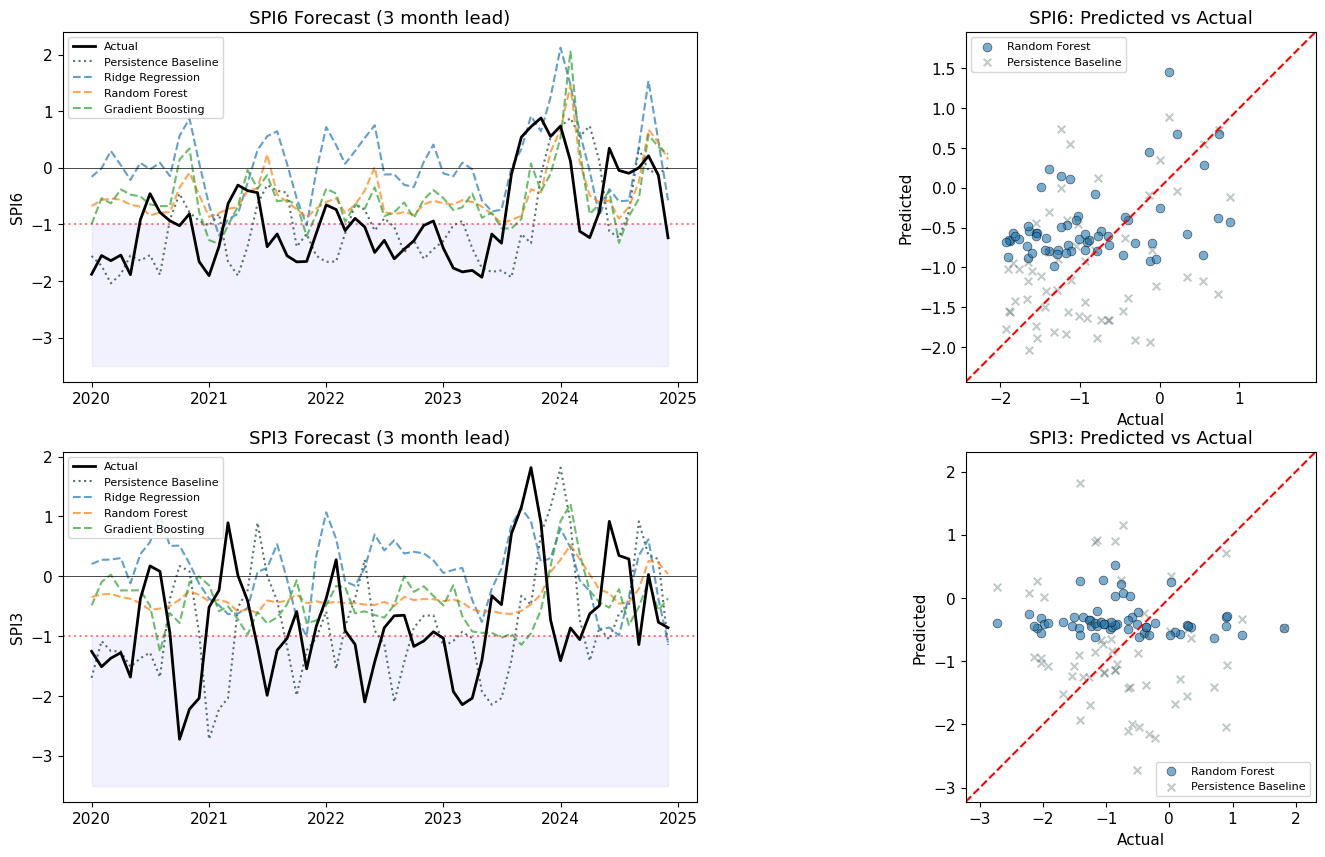

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

def plot_forecast(ax, y_test, predictions, title):
    ax.plot(y_test.index, y_test.values, "k-", linewidth=2, label="Actual", zorder=5)
    ax.plot(y_test.index, predictions["Persistence Baseline"], ":", color=bcolor, linewidth=1.5, alpha=0.8, label="Persistence Baseline")

    ml_names = [n for n in predictions if n not in ["Climatology Baseline", "Persistence Baseline"]]
    for name in ml_names:
        ax.plot(y_test.index, predictions[name], "--", alpha=0.7, linewidth=1.5, label=name)

    ax.axhline(y=-1.0, color="red", linestyle=":", alpha=0.5)
    ax.fill_between(y_test.index, -1, -3.5, color="blue", alpha=0.05)
    ax.axhline(y=0, color="black", linewidth=0.5)
    ax.set_ylabel(title.split(" ")[0])
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=8, loc="upper left")

def plot_scatter(ax, y_test, predictions, persist_pred, title):
    ml_names = [n for n in predictions if n not in ["Climatology Baseline", "Persistence Baseline"]]
    best_name = ml_names[0]
    best_rmse = np.sqrt(mean_squared_error(y_test, predictions[best_name]))
    for name in ml_names[1:]:
        rmse = np.sqrt(mean_squared_error(y_test, predictions[name]))
        if rmse < best_rmse:
            best_name = name
            best_rmse = rmse
    
    ax.scatter(y_test, predictions[best_name], alpha=0.6, edgecolors="black", 
               linewidth=0.5, s=40, label=best_name)
    ax.scatter(y_test, persist_pred, alpha=0.3, marker="x", 
               color=bcolor, s=30, label="Persistence Baseline")
    
    lims = [min(y_test.min(), predictions[best_name].min()) - 0.5,
            max(y_test.max(), predictions[best_name].max()) + 0.5]
    ax.plot(lims, lims, "r--", linewidth=1.5)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.set_title(title, fontsize=13)
    ax.set_aspect("equal")
    ax.legend(fontsize=8)

plot_forecast(axes[0, 0], y_test6, predictions_6, "SPI6 Forecast (3 month lead)")
plot_scatter(axes[0, 1], y_test6, predictions_6, predictions_6["Persistence Baseline"], "SPI6: Predicted vs Actual")
plot_forecast(axes[1, 0], y_test3, predictions_3, "SPI3 Forecast (3 month lead)")
plot_scatter(axes[1, 1], y_test3, predictions_3, predictions_3["Persistence Baseline"], "SPI3: Predicted vs Actual")